In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv('data/Heart_disease_cleveland_new.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [5]:
import sklearn

In [6]:
data_x = data.drop('target', axis=1)
data_y = data['target']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    data_x, data_y, test_size=0.2, stratify=data_y, random_state=100
)
print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")



Train: 242 samples, Test: 61 samples


In [7]:
data_x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1


In [8]:
data_y.head()

0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

In [9]:
from sklearn.metrics import roc_curve

def linear_logistic_model(X_train, y_train, X_test, y_test, normalize=False, standardize=False, plot_roc=False):
    if normalize:
        X_train = X_train / X_train.max(axis=0)
        X_test = X_test / X_test.max(axis=0)
    if standardize:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
    model = LogisticRegression(max_iter=1000, random_state=100)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)
    rs = recall_score(y_test, y_pred)
    ps = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    
    label = f'norm={normalize}, stand={standardize} (AUC={auc:.3f})'
    
    print(f'model: {model} + normalize: {normalize} + standardize: {standardize}')
    print(f'cm: {cm}')
    print(f'recall_score: {rs}')
    print(f'f1_score: {f1}')
    print(f'precision_score: {ps}')
    print(f'auc: {auc}')
    
    return cm, rs, ps, f1, auc, fpr, tpr, label

model: LogisticRegression(max_iter=1000, random_state=100) + normalize: True + standardize: True
cm: [[26  7]
 [ 7 21]]
recall_score: 0.75
f1_score: 0.75
precision_score: 0.75
auc: 0.8809523809523809
model: LogisticRegression(max_iter=1000, random_state=100) + normalize: True + standardize: False
cm: [[28  5]
 [ 8 20]]
recall_score: 0.7142857142857143
f1_score: 0.7547169811320755
precision_score: 0.8
auc: 0.8625541125541125
model: LogisticRegression(max_iter=1000, random_state=100) + normalize: False + standardize: True
cm: [[28  5]
 [ 8 20]]
recall_score: 0.7142857142857143
f1_score: 0.7547169811320755
precision_score: 0.8
auc: 0.8777056277056277
model: LogisticRegression(max_iter=1000, random_state=100) + normalize: False + standardize: False
cm: [[29  4]
 [ 8 20]]
recall_score: 0.7142857142857143
f1_score: 0.7692307692307693
precision_score: 0.8333333333333334
auc: 0.8798701298701299


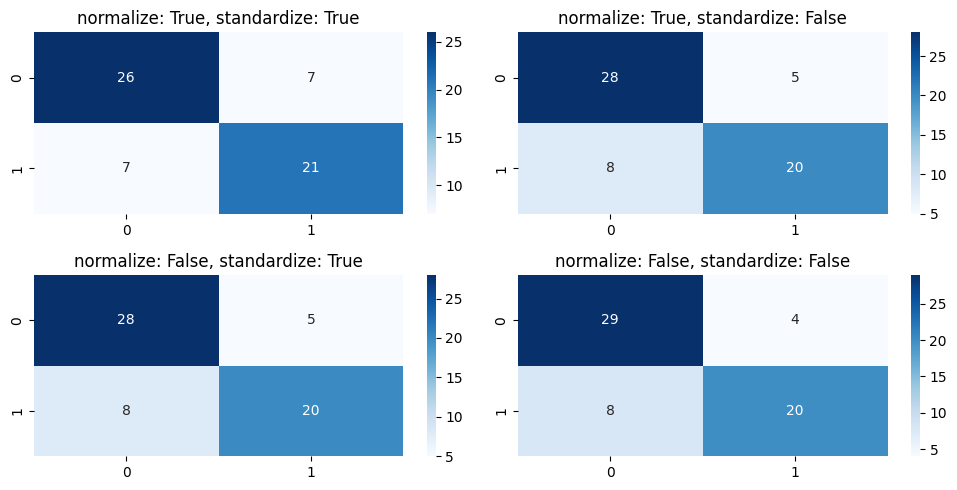

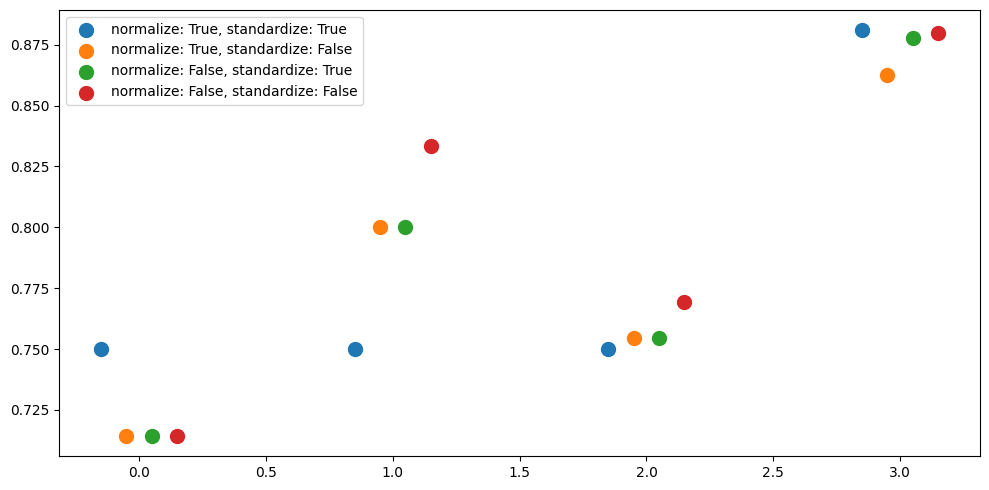

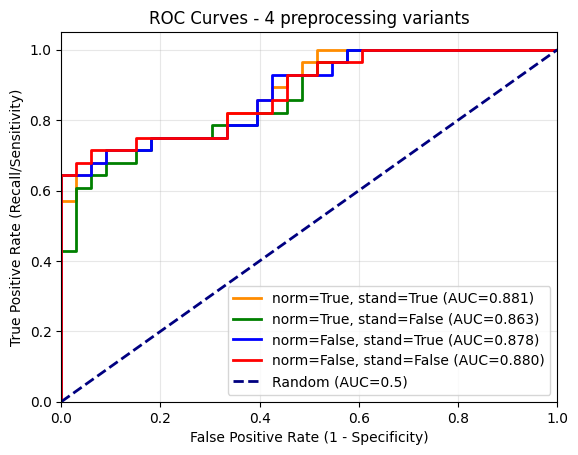

In [10]:
results = []
roc_data = []

for normalize in [True, False]:
    for standardize in [True, False]:
        cm, rs, ps, f1, auc, fpr, tpr, label = linear_logistic_model(
            X_train, y_train, X_test, y_test, 
            normalize=normalize, standardize=standardize
        )
        results.append((normalize, standardize, cm, rs, ps, f1, auc))
        roc_data.append((fpr, tpr, label, auc))

ax, axes = plt.subplots(2, 2, figsize=(10, 5))
axes = axes.flatten()
for i in range(len(results)):
    normalize, standardize, cm, _, _, _, _ = results[i]
    axes[i].set_title(f'normalize: {normalize}, standardize: {standardize}')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
plt.tight_layout()
plt.show()

metrics = ['recall', 'precision', 'f1', 'auc']
x_pos = np.arange(len(metrics))
offsets = np.linspace(-0.15, 0.15, len(results))

plt.figure(figsize=(10, 5))
for i in range(len(results)):
    normalize, standardize, _, rs, ps, f1, auc = results[i]
    label = f'normalize: {normalize}, standardize: {standardize}'
    plt.scatter(x_pos + offsets[i], [rs, ps, f1, auc], label=label, s=100)
plt.legend()
plt.tight_layout()
plt.show()


colors = ['darkorange', 'green', 'blue', 'red']

for i, (fpr, tpr, label, auc) in enumerate(roc_data):
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=label)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC=0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('ROC Curves - 4 preprocessing variants')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

/home/pawel/Desktop/Studia/sem2/ML/lista-3-Pewciu6/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pawel/Desktop/Studia/sem2/ML/lista-3-Pewciu6/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pawel/Desktop/Studia/sem2/ML/lista-3-Pewciu6/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:

,C,l1_ratio,roc_auc_mean,roc_auc_std,n_iter
0,0.01,0.2,0.893104,0.065209,15
1,0.01,0.5,0.836972,0.063262,16
2,0.01,0.8,0.500000,0.000000,8
3,0.10,0.2,0.899019,0.058570,15
4,0.10,0.5,0.896825,0.062153,16
5,0.10,0.8,0.896401,0.061656,16
6,1.00,0.2,0.901257,0.057719,18
7,1.00,0.5,0.900586,0.058247,18
8,1.00,0.8,0.899058,0.059794,18
9,10.00,0.2,0.899296,0.059462,19


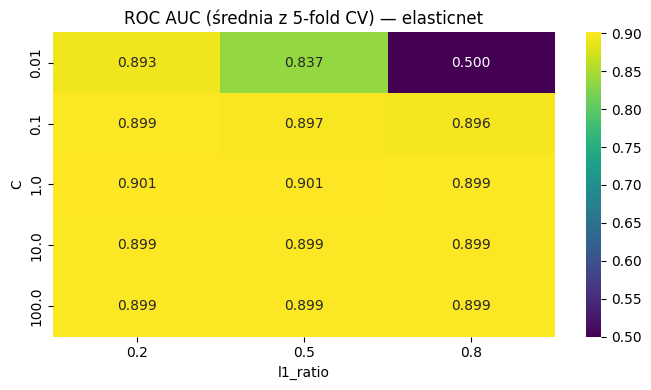

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

# C i l1_ratio (elasticnet + saga), bez GridSearch — CV w pipeline (skalowanie w każdym foldzie)
X = data.drop('target', axis=1)
y = data['target']
skf_hp = StratifiedKFold(n_splits=5, shuffle=True, random_state=100)

Cs = np.logspace(-2, 2, 5)
l1_ratios = [0.2, 0.5, 0.8]

rows_hp = []
for C in Cs:
    for l1_ratio in l1_ratios:
        clf = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            C=float(C),
            l1_ratio=l1_ratio,
            max_iter=10000,
            random_state=100,
        )
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
        scores = cross_val_score(pipe, X, y, cv=skf_hp, scoring='roc_auc')
        pipe.fit(X, y)
        n_it = int(pipe.named_steps['clf'].n_iter_[0])
        rows_hp.append({
            'C': C,
            'l1_ratio': l1_ratio,
            'roc_auc_mean': scores.mean(),
            'roc_auc_std': scores.std(),
            'n_iter': n_it,
        })

df_hp = pd.DataFrame(rows_hp)
display(df_hp)

pivot = df_hp.pivot(index='C', columns='l1_ratio', values='roc_auc_mean')
plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title('ROC AUC (średnia z 5-fold CV) — elasticnet')
plt.ylabel('C')
plt.xlabel('l1_ratio')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

X = data.drop('target', axis=1)
y = data['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000, random_state=100)

rows_cv = []
for n_splits in [2, 3, 4, 5, 7, 10]:
    scores = cross_val_score(model, X_scaled, y, cv=n_splits, scoring='roc_auc')
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=100)
    scores_strat = cross_val_score(model, X_scaled, y, cv=skf, scoring='roc_auc')
    rows_cv.append({
        'n_splits': n_splits,
        'cv=int mean': scores.mean(),
        'cv=int std': scores.std(),
        'StratifiedKFold mean': scores_strat.mean(),
        'StratifiedKFold std': scores_strat.std(),
    })

df_cv = pd.DataFrame(rows_cv)
display(df_cv.round(4))


,n_splits,cv=int mean,cv=int std,StratifiedKFold mean,StratifiedKFold std
0,2,0.9036,0.0243,0.8843,0.0087
1,3,0.9041,0.0079,0.9060,0.0209
2,4,0.9013,0.0293,0.9044,0.0210
3,5,0.9020,0.0250,0.9017,0.0571
4,7,0.9041,0.0392,0.9009,0.0434
5,10,0.9068,0.0367,0.9067,0.0554


## Podsumowanie

Zgodnie z celem listy (pipeline, nie „dobijanie” accuracy):

- **Dane:** HDC, 303 wiersze, klasyfikacja binarna; train/test z `stratify` żeby zachować proporcje klas.
- **Model:** `LogisticRegression`, ocena na teście.
- **Metryki:** m.in. precision i recall — przy wykrywaniu choroby ważniejszy recall (nie przeoczyć chorego), precision mówi ile alarmów jest fałszywych. Dodatkowo macierz pomyłek, ROC/AUC.
- **Skalowanie:** porównane kombinacje standaryzacji i normalizacji — AUC i tak podobne; sens ma skalowanie ze względu na skale cech.
- **Hiperparametry:** siatka `C` × `l1_ratio` dla `penalty='elasticnet'`, `solver='saga'` — tabela + heatmapa ROC AUC z 5-fold CV (Pipeline ze skalowaniem); kolumna `n_iter` po dopasowaniu na całym zbiorze (widać, czy trzeba podbijać `max_iter`).
- **CV:** różne `n_splits` (m.in. 2, 5, 10), `cross_val_score` z `cv=int` vs z jawnym `StratifiedKFold(shuffle=True)` — średnia ± std AUC; liczby blisko siebie.

Ogólnie model na tym zbiorze wygląda OK, ale sens ma patrzeć na kilka metryk naraz i na rozrzut z CV, nie tylko na jeden wynik z jednego podziału.